In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\USER\Desktop\Telecom-Customer-Churn-Analysis\data\cleaned\cleaned_telco_churn.csv"
)

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7032, 21)

In [4]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100


Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [6]:
import matplotlib.pyplot as plt

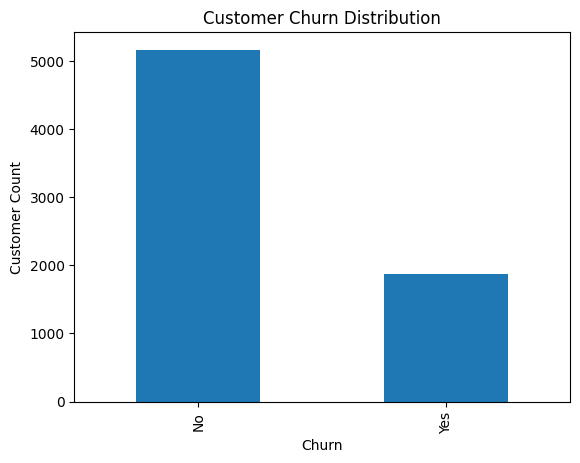

In [7]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()

In [8]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


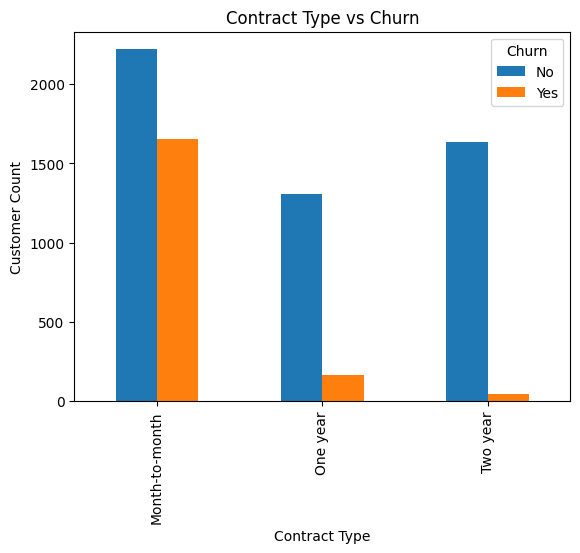

In [9]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(kind="bar")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()

Here we can see custumers who have long plans have high retention. Than of monthly plans. So here we can put forward more offers for monthly users to shift to yearly plans

In [10]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

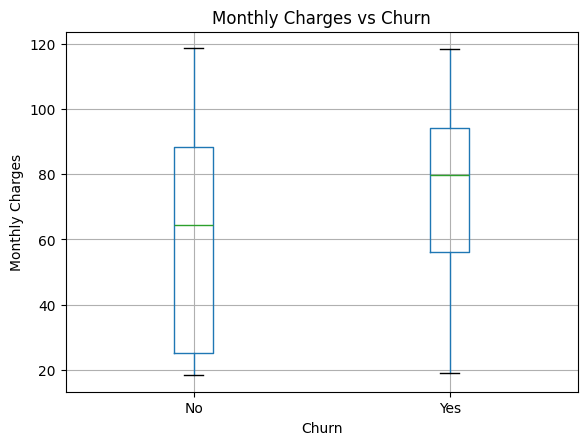

In [11]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Customers with higher monthly charges are more likely to churn, suggesting pricing sensitivity or dissatisfaction with premium plans.
Introduce loyalty discounts or bundled offers for high-paying customers to improve retention.

In [13]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

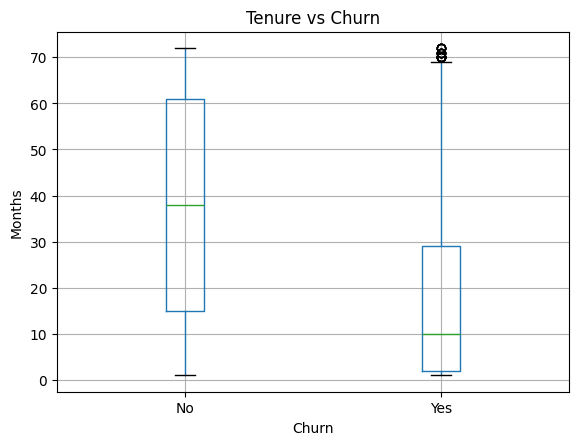

In [14]:
df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Months")
plt.show()

Customers with shorter tenure are more likely to churn, indicating early-stage customer retention is critical.
    Improve onboarding experience and provide retention offers during the first few months.

Focus retention campaigns on new customers (0–12 months) through onboarding offers, discounts, and customer support.

In [15]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


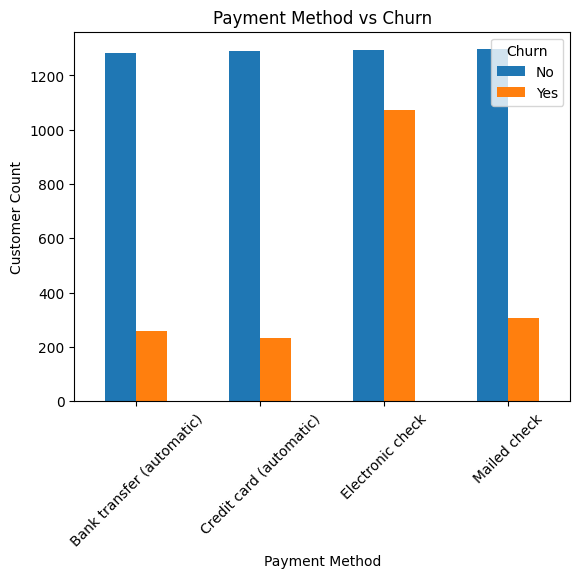

In [16]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
).plot(kind="bar")

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.show()

Customers using electronic check payment methods show higher churn,

Encourage auto-pay or credit card payment with cashback/discount incentives.

In [17]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


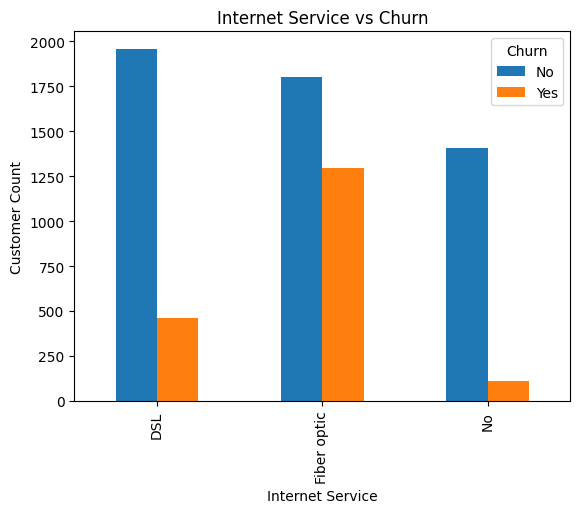

In [18]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
).plot(kind="bar")

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.show()

Fiber optic users show higher churn
Premium customers pay more and may have higher expectations, so dissatisfaction leads to churn faster.

In [19]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


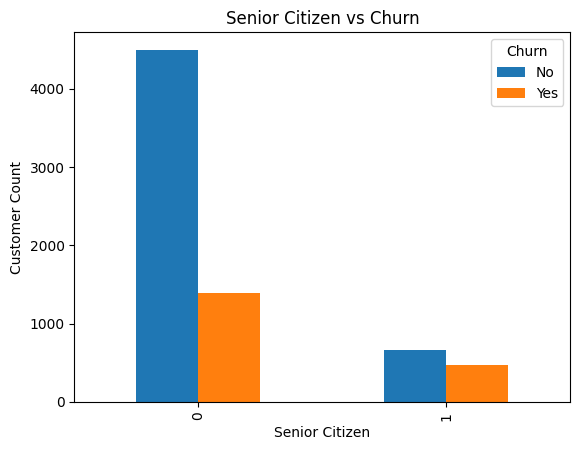

In [20]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
).plot(kind="bar")

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Customer Count")
plt.show()

Senior citizens exhibit relatively higher churn, suggesting this segment may require better customer support or simplified service plans.

In [21]:
pd.crosstab(
    df["gender"],
    df["Churn"]
)

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


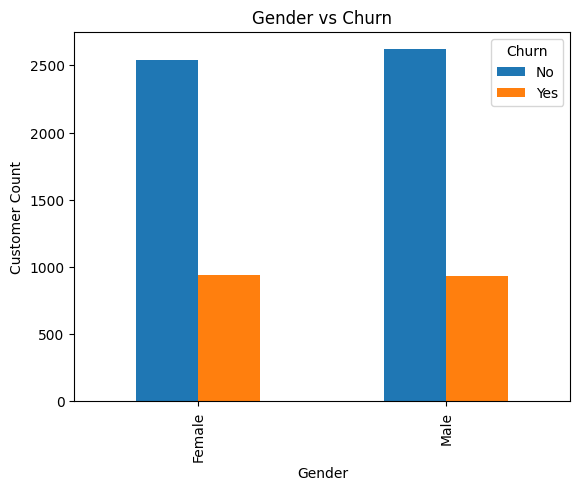

In [22]:
pd.crosstab(
    df["gender"],
    df["Churn"]
).plot(kind="bar")

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

Customer churn appears relatively balanced across gender, suggesting gender is not a major influencing factor.

# Key Business Insights

1. Customers on month-to-month contracts show the highest churn, while 2-year contracts have the strongest retention.

2. Customers with higher monthly charges are more likely to churn.

3. New customers (low tenure) exhibit significantly higher churn rates, indicating onboarding is critical.

4. Customers using Electronic Check payment methods show higher churn.

5. Fiber optic users demonstrate higher churn compared to DSL customers.

6. Senior citizens show relatively higher churn and may require targeted retention strategies.

7. Gender does not appear to significantly influence churn behavior.